# 🍜 Analisis Klaster Pola Pengeluaran Makanan & Minuman Jadi di Jawa Timur 2024
**Mata Kuliah:** Pemodelan Statistik Terapan  
**Framing Industri:** FMCG & Consumer Analytics Insights (Regional Distribution & Pricing Strategy)  
**Metodologi:** Agglomerative Hierarchical Clustering (StandardScaler, Linkage Comparison, Cophenetic Correlation, Per-Sample Silhouette Analysis)

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
root_path = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import src
from src.clustering import (
    calculate_cophenetic_correlation,
    compare_linkage_methods,
    fit_hierarchical_clustering,
    compute_sample_silhouette,
    get_cluster_profiles,
    get_gap_analysis,
    assign_business_cluster_names,
    get_business_recommendations
)
from src.visualization import (
    plot_dendrogram,
    plot_silhouette_sample_analysis,
    plot_pca_2d_interactive,
    plot_cluster_distribution_interactive,
    plot_cluster_profile_heatmap_interactive,
    plot_top_features_interactive,
    plot_gap_analysis_interactive,
    plot_east_java_map_interactive
)

print('Libraries and custom modules successfully loaded.')

Libraries and custom modules successfully loaded.


## 1. Data Ingestion & Inspeksi Awal
Dataset bersumber dari Badan Pusat Statistik (BPS) Jawa Timur yang mencatat rata-rata pengeluaran per kapita seminggu untuk komoditas makanan dan minuman jadi di seluruh 38 Kabupaten/Kota tahun 2024.

In [2]:
df_raw = src.load_raw_data()
print(f'Dimensi Data Mentah: {df_raw.shape[0]} Wilayah x {df_raw.shape[1]} Kolom')
df_raw.head()

Dimensi Data Mentah: 38 Wilayah x 33 Kolom


,Kabupaten/Kota,Roti tawar,"Roti manis, roti lainnya","Kue kering, biskuit, semprong","Kue basah (kue lapis, bika ambon, lemper, dsb)","Makanan gorengan (tahu, tempe, bakwan, pisang)",Makanan gorengan,Bubur kacang hijau,"Gado-gado, ketoprak, pecel",Nasi campur/rames,...,"Siomay, batagor",Makanan jadi lainnya,Air kemasan,Air kemasan galon,"Air teh kemasan, minuman bersoda/mengandung CO2","Sari buah kemasan, minuman kesehatan, minuman berenergi","Minuman jadi (kopi, kopi susu, teh, susu coklat, dsb)",Es krim,Es lainnya,Minuman keras
0,Pacitan,81,1596,974,1933,2443,181,415,779,8286,...,910,426,431,405,180,259,7190,571,461,-
1,Ponorogo,212,1196,1026,2042,2714,191,436,2035,3724,...,652,1462,231,1453,281,222,4363,758,1418,-
2,Trenggalek,72,824,820,1583,1446,105,613,681,6858,...,499,637,291,674,230,234,2706,688,587,1
3,Tulungagung,125,1264,761,1958,1706,172,371,2156,2962,...,654,1015,451,1483,711,198,3829,774,1156,31
4,Blitar,119,1205,1139,1561,1722,202,226,1902,6735,...,464,1390,351,751,537,293,2522,911,933,8


In [3]:
df_clean, regions, df_numeric = src.clean_data(df_raw)
print(f'Fitur Numerik Teridentifikasi: {df_numeric.shape[1]} kolom')

Fitur Numerik Teridentifikasi: 32 kolom


## 2. Preprocessing & Justifikasi Metodologis
### 2.1 Justifikasi Statistik Penghapusan Fitur `Minuman keras`
Sebelum melakukan penghapusan fitur, kami melakukan pengujian empiris kuantitatif pada missing rate, rasio varians, dan korelasi.

In [4]:
drop_diag = src.analyze_dropped_feature(df_numeric, 'Minuman keras')
print(drop_diag['justification'])

Justifikasi Statistik Penghapusan Fitur 'Minuman keras':
1. Missing Rate: 34.2% (13 dari 38 wilayah tidak memiliki data konsumsi / bernilai '-').
2. Varians Sangat Rendah: Varians fitur ini (661.42) jauh di bawah rerata varians fitur lainnya (819,142.53), menunjukkan daya pembeda (discriminatory power) yang sangat minim dalam membedakan karakteristik klaster.
3. Korelasi Rata-rata Lemah: Rerata korelasi dengan kelompok pengeluaran lain adalah -0.025 (rentang: -0.256 s/d 0.305).
Kesimpulan: Penghapusan fitur ini mencegah penambahan dimensi dengan informasi mendekati konstan yang dapat mendistorsi jarak Euclidean.


In [5]:
# Drop fitur Minuman keras secara terjustifikasi
df_features = df_numeric.drop(columns=['Minuman keras'], errors='ignore')
feature_names = df_features.columns.tolist()
print(f'Jumlah fitur final untuk pemodelan: {len(feature_names)} komoditas')

Jumlah fitur final untuk pemodelan: 31 komoditas


### 2.2 Deteksi & Rationale Penanganan Outlier (IQR Method)
Karena data ini merupakan data sensus populasi (38 Kabupaten/Kota se-Jawa Timur), pencilan tinggi pada Kota Surabaya dan Kota Malang mencerminkan fenomena ekonomi nyata. Outlier dipertahankan untuk mendeteksi segmen metropolitan.

In [6]:
outlier_res = src.detect_outliers_iqr(df_features, region_names=regions)
print(outlier_res['methodology_rationale'])
outlier_res['summary_table'].head(10)

Justifikasi Pengelolaan Outlier (Population Census Perspective):
Dataset ini merepresentasikan seluruh 38 Kabupaten/Kota di Provinsi Jawa Timur (data populasi, bukan sampel acak). Nilai ekstrem yang terdeteksi (seperti tingginya pengeluaran di Kota Surabaya dan Kota Malang) mencerminkan disparitas sosio-ekonomi nyata antara wilayah metropolitan vs perdesaan. Oleh karena itu, outlier TIDAK dihapus atau dipangkas (winsorized), melainkan dipertahankan agar segmentasi klaster mampu mengidentifikasi klaster bernilai tinggi (high-spending urban segment) secara akurat.


,Fitur,Jumlah Outlier,Persentase (%),Batas Bawah,Batas Atas,Wilayah Terdeteksi
0,Bubur ayam,4,10.5,-278.62,864.38,"Sidoarjo, Kota Kediri, Kota Madiun, Kota Surabaya"
1,Air kemasan,3,7.9,-341.50,1784.50,"Gresik, Sumenep, Kota Surabaya"
2,Roti tawar,3,7.9,-209.50,814.50,"Gresik, Kota Malang, Kota Surabaya"
3,"Makanan gorengan (tahu, tempe, bakwan, pisang)",2,5.3,608.00,3870.00,"Ngawi, Gresik"
4,Makanan gorengan,2,5.3,-176.50,783.50,"Kota Kediri, Kota Surabaya"
5,Air kemasan galon,2,5.3,-2196.62,5464.38,"Gresik, Kota Surabaya"
6,Bubur kacang hijau,2,5.3,-92.75,1005.25,"Kota Kediri, Kota Madiun"
7,"Gado-gado, ketoprak, pecel",2,5.3,94.38,3869.38,"Kota Madiun, Kota Surabaya"
8,"Sayur matang (ditumis, disantan, dsb)",2,5.3,-237.25,2418.75,"Kota Kediri, Kota Blitar"
9,"Mie bakso, mie rebus, mie goreng",2,5.3,1770.88,9325.88,"Kota Pasuruan, Kota Surabaya"


### 2.3 Standardisasi Fitur (Z-score Normalization)
Menggunakan `StandardScaler` agar perbedaan skala nominal antar komoditas tidak mendominasi perhitungan jarak Euclidean.

In [7]:
df_scaled, scaler = src.scale_features(df_features, index_series=regions)
df_scaled.head()

,Roti tawar,"Roti manis, roti lainnya","Kue kering, biskuit, semprong","Kue basah (kue lapis, bika ambon, lemper, dsb)","Makanan gorengan (tahu, tempe, bakwan, pisang)",Makanan gorengan,Bubur kacang hijau,"Gado-gado, ketoprak, pecel",Nasi campur/rames,Nasi goreng,...,Bubur ayam,"Siomay, batagor",Makanan jadi lainnya,Air kemasan,Air kemasan galon,"Air teh kemasan, minuman bersoda/mengandung CO2","Sari buah kemasan, minuman kesehatan, minuman berenergi","Minuman jadi (kopi, kopi susu, teh, susu coklat, dsb)",Es krim,Es lainnya
Kabupaten/Kota,,,,,,,,,,,,,,,,,,,,,
Pacitan,-0.961526,-0.165180,-0.888527,-0.489412,0.221326,-0.745194,-0.237350,-1.505737,1.489624,-1.242590,...,-0.806210,-0.179553,-1.986834,-0.665144,-0.929214,-1.327915,-0.619002,2.693710,-1.679710,-1.736565
Ponorogo,-0.486441,-0.840834,-0.779712,-0.331363,0.631847,-0.687415,-0.151763,-0.083412,-0.424648,-1.209518,...,-0.472827,-0.711698,-0.573227,-0.998329,-0.273840,-0.885238,-0.776241,0.466502,-0.997379,-0.299072
Trenggalek,-0.994165,-1.469192,-1.210787,-0.996911,-1.288968,-1.184312,0.569619,-1.616715,0.890418,-1.396445,...,-0.863129,-1.027272,-1.698928,-0.898374,-0.760993,-1.108768,-0.725244,-0.838940,-1.252797,-1.547303
Tulungagung,-0.801956,-0.725973,-1.334250,-0.453162,-0.895110,-0.797195,-0.416677,0.053611,-0.744393,-0.490569,...,-0.180101,-0.707572,-1.183152,-0.631825,-0.255080,0.999425,-0.878233,0.045798,-0.938998,-0.692618
Blitar,-0.823715,-0.825632,-0.543249,-1.028811,-0.870873,-0.623859,-1.007639,-0.234024,0.838805,-0.796842,...,-0.643585,-1.099462,-0.671470,-0.798418,-0.712840,0.236794,-0.474512,-0.983902,-0.439108,-1.027582


## 3. Eksplorasi Metodologis: Evaluasi 4 Metode Linkage
Kami mengevaluasi 4 metode linkage (`Ward`, `Complete`, `Average`, `Single`) berdasarkan Silhouette Score (K=2 s/d 10) dan *Cophenetic Correlation Coefficient*.

In [8]:
scores_df, summary_eval = src.compare_linkage_methods(df_scaled.values)
summary_eval

,Metode Linkage,Best K,Best Silhouette,Cophenetic Corr,Status
0,Single,2,0.4153,0.8115,Komparator
1,Average,2,0.3664,0.7944,Komparator
2,Complete,2,0.3620,0.7592,Komparator
3,Ward,2,0.3113,0.6379,Dipilih (Ward)


In [9]:
fig_linkage = src.visualization.plot_linkage_comparison_interactive(scores_df, chosen_method='ward', chosen_k=3)
fig_linkage.show()

## 4. Pemodelan Hierarchical Clustering (Ward, K=3)
Metode Ward dipilih karena menghasilkan klaster yang homogen dengan ukuran klaster yang berimbang secara manajerial.

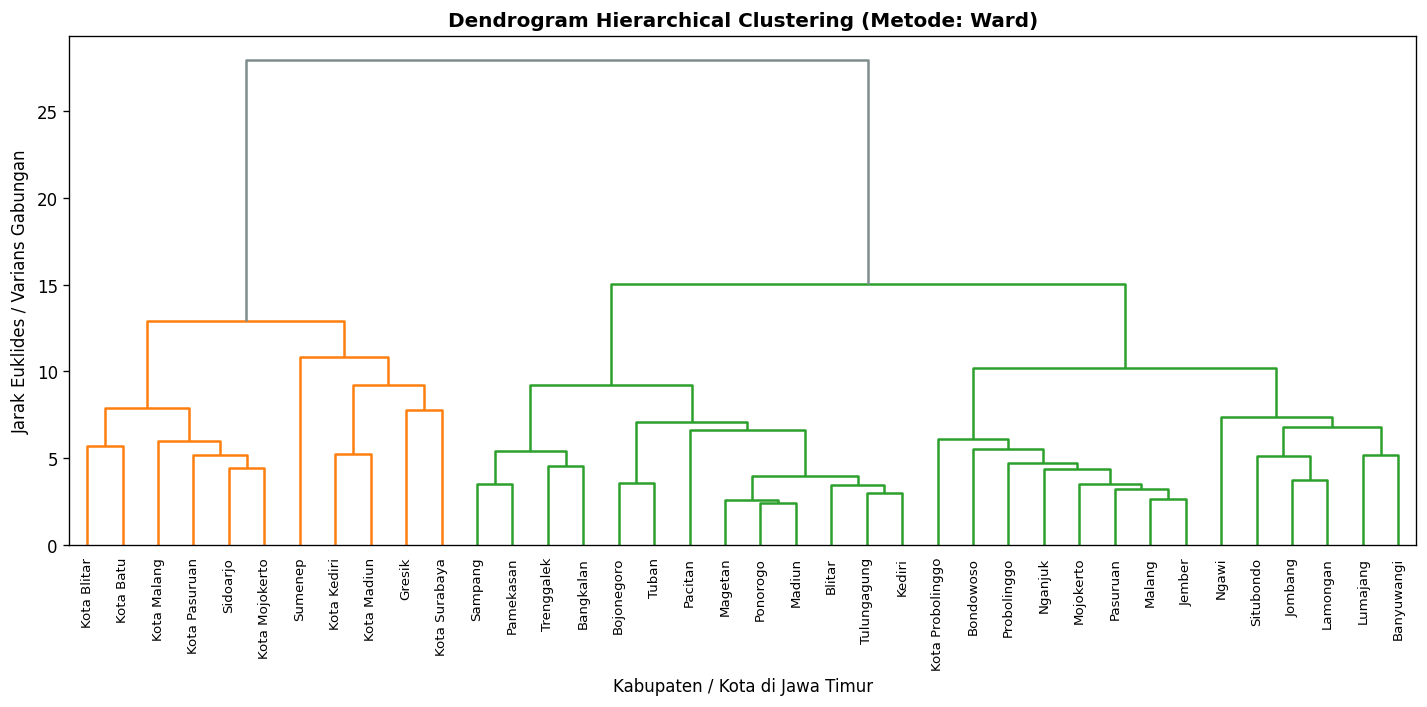

In [10]:
fig_dendro = plot_dendrogram(df_scaled.values, labels=regions.tolist(), method='ward')
plt.show()

Silhouette Score Ward (K=3): 0.1356


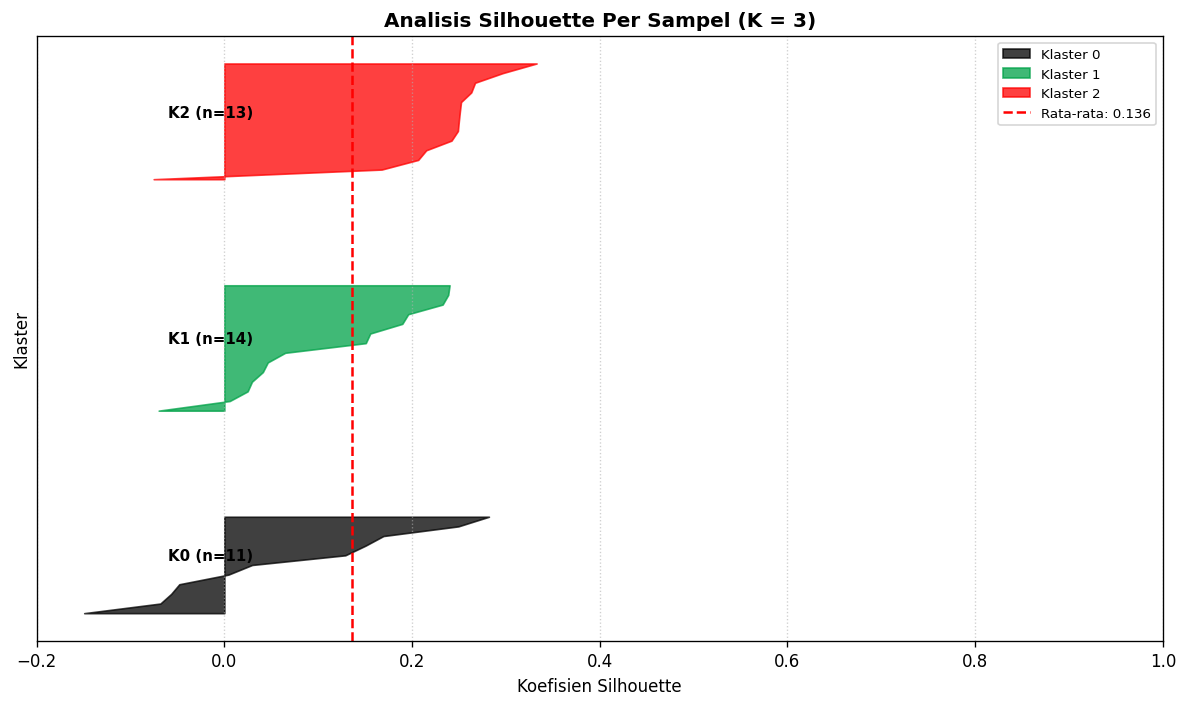

In [11]:
model, labels, sil_score = fit_hierarchical_clustering(df_scaled.values, n_clusters=3, linkage_method='ward')
print(f'Silhouette Score Ward (K=3): {sil_score:.4f}')

fig_sil_sample = plot_silhouette_sample_analysis(df_scaled.values, labels, n_clusters=3)
plt.show()

## 5. Visualisasi Hasil Klastering
### 5.1 Proyeksi 2D PCA & Distribusi Anggota

In [12]:
median_prof_raw, _ = get_cluster_profiles(df_features, labels)
cluster_name_map = assign_business_cluster_names(median_prof_raw)

named_labels = [cluster_name_map.get(f'Klaster {lbl}', f'Klaster {lbl}') for lbl in labels]
df_result = df_features.copy()
df_result['Kabupaten/Kota'] = regions.values
df_result['Cluster_ID'] = labels
df_result['Nama_Klaster'] = named_labels
df_result['Total_Pengeluaran'] = df_features.sum(axis=1)

fig_pca = plot_pca_2d_interactive(df_scaled, labels, regions, cluster_name_map, df_raw_features=df_features)
fig_pca.show()

In [13]:
fig_dist = plot_cluster_distribution_interactive(df_result, cluster_col='Nama_Klaster')
fig_dist.show()

### 5.2 Peta Persebaran Spasial Jawa Timur

In [14]:
fig_map = plot_east_java_map_interactive(df_result, total_spending_col='Total_Pengeluaran')
fig_map.show()

## 6. Business Insights & FMCG Strategic Recommendations
### 6.1 Analisis Disparitas Pengeluaran (Gap Analysis)

In [15]:
median_prof_named, mean_prof_named = get_cluster_profiles(df_features, labels, label_names=cluster_name_map)
gap_df = get_gap_analysis(median_prof_named)
gap_df.head(10)

,Komoditas / Fitur,Klaster Tertinggi,Nilai Tertinggi (Rp),Klaster Terendah,Nilai Terendah (Rp),Gap Ratio (X kali),Gap Absolut (Rp)
0,Bubur ayam,Klaster 0,735.0,Klaster 2,171.0,4.30,564.0
1,Air kemasan galon,Klaster 0,2782.0,Klaster 2,751.0,3.70,2031.0
2,Roti tawar,Klaster 0,635.0,Klaster 2,173.0,3.67,462.0
3,Nasi goreng,Klaster 0,4198.0,Klaster 2,1228.0,3.42,2970.0
4,Air kemasan,Klaster 0,1090.0,Klaster 2,381.0,2.86,709.0
5,"Ayam/daging matang (ayam goreng, rendang, dsb)",Klaster 0,3729.0,Klaster 2,1309.0,2.85,2420.0
6,Ikan matang,Klaster 0,900.0,Klaster 2,318.0,2.83,582.0
7,Makanan gorengan,Klaster 0,464.0,Klaster 2,181.0,2.56,283.0
8,Nasi campur/rames,Klaster 0,7699.0,Klaster 1,3033.0,2.54,4666.0
9,"Siomay, batagor",Klaster 0,1537.0,Klaster 2,654.0,2.35,883.0


In [16]:
fig_gap = plot_gap_analysis_interactive(gap_df, top_n=10)
fig_gap.show()

### 6.2 Top Komoditas & Rekomendasi Aksi Industri

In [17]:
fig_top = plot_top_features_interactive(median_prof_named, top_n=10)
fig_top.show()

In [18]:
recs = get_business_recommendations()
for cluster_title, rec_body in recs.items():
    print('=' * 80)
    print(f'SEGMEN: {cluster_title}')
    print(f'WHO: {rec_body["who"]}')
    print(f'WHAT: {rec_body["what"]}')
    print(f'SO WHAT: {rec_body["so_what"]}')
    print('NOW WHAT:')
    print(f'  - FMCG Strategy: {rec_body["now_what"]["fmcg"]}')
    print(f'  - Food Delivery: {rec_body["now_what"]["food_delivery"]}')
    print(f'  - Kebijakan Pemda: {rec_body["now_what"]["pemprov"]}')

SEGMEN: 🏙️ Urban High-Spender (Metropolitan)
WHO: Pusat pertumbuhan ekonomi kota besar (cth: Kota Surabaya, Kota Malang, Sidoarjo). Karakteristik penduduk berpendapatan tinggi, mobilitas cepat, dan gaya hidup instan.
WHAT: Pengeluaran tertinggi pada: Nasi campur/rames, Mie bakso, Ayam/daging olahan matang, dan Minuman jadi (kopi susu & teh siap saji).
SO WHAT: Pasar dengan purchasing power tertinggi. Konsumen mengutamakan kepraktisan, brand reputation, dan higienitas dibandingkan harga murah.
NOW WHAT:
  - FMCG Strategy: Perbanyak penetrasi produk Ready-to-Drink (RTD) premium, frozen meal siap saji, dan paket bumbu gourmet di modern trade (supermarket/minimarket).
  - Food Delivery: Prioritaskan ekspansi mitra restoran premium, bundling menu makan siang perkantoran, dan fitur pesan terjadwal.
  - Kebijakan Pemda: Fokus pada pengawasan higienitas sanitasi kuliner jalanan dan edukasi pengurangan kadar gula pada minuman kekinian.
SEGMEN: 🏘️ Suburban Moderate (Sentra Industri & Pertumbuhan

## 7. Ekspor Data Hasil Segmentasi

In [19]:
output_path = root_path / 'data' / 'processed' / 'hasil_klaster_konsumsi_jatim_2024.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
df_result.to_csv(output_path, index=False)
print(f'Data hasil segmentasi berhasil diekspor ke: {output_path}')

Data hasil segmentasi berhasil diekspor ke: D:\ARFI\Kuliah\Semester 2\Pemodelan Statistik Terapan\Proyek Akhir\data\processed\hasil_klaster_konsumsi_jatim_2024.csv
